In [10]:
import scipy.stats as stats

# Lấy độ dài output hoặc ground truth để kiểm tra phân phối
lengths = df_merge["len_output"].values   # hoặc df_merge["len_truth"].values

# Shapiro-Wilk test
stat, p = stats.shapiro(lengths)
print("Shapiro-Wilk test p-value:", p)

if p > 0.05:
    print("Phân phối gần giống chuẩn")
else:
    print("Phân phối khác chuẩn")


Shapiro-Wilk test p-value: 0.11861862779482646
Phân phối gần giống chuẩn


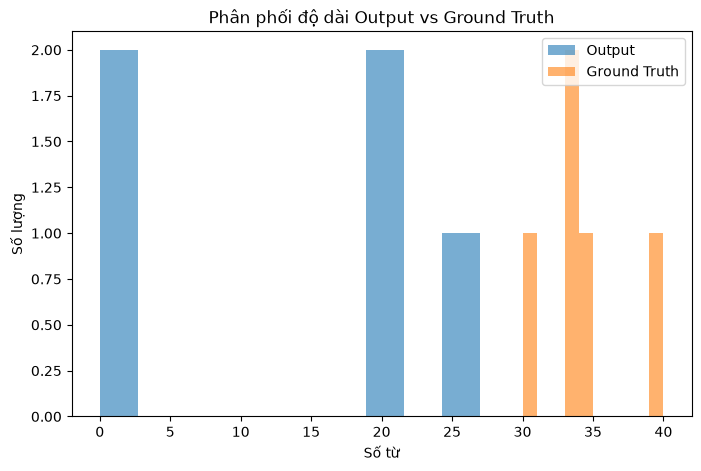

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_merge["len_output"], bins=10, alpha=0.6, label="Output")
plt.hist(df_merge["len_truth"], bins=10, alpha=0.6, label="Ground Truth")
plt.xlabel("Số từ")
plt.ylabel("Số lượng")
plt.title("Phân phối độ dài Output vs Ground Truth")
plt.legend()
plt.show()


In [7]:
# Đảm bảo không có NaN, chuyển tất cả sang chuỗi
df_merge["generated_gherkin"] = df_merge["generated_gherkin"].fillna("").astype(str)
df_merge["expected_scenario"] = df_merge["expected_scenario"].fillna("").astype(str)

# Tính độ dài (số từ)
df_merge["len_output"] = df_merge["generated_gherkin"].apply(lambda x: len(str(x).split()))
df_merge["len_truth"] = df_merge["expected_scenario"].apply(lambda x: len(str(x).split()))

print(df_merge[["story", "len_output", "len_truth"]])


                                               story  len_output  len_truth
0   I want to stay logged in so that I don’t have...          20         34
1   I want to add items to my shopping cart so th...          21         33
2   I want to view my grades online so that I can...           0         30
3   I want to book appointments online so that I ...           0         33
4   I want to transfer money between accounts so ...          27         40


In [5]:
# Ghép theo story
df_merge = pd.merge(df_output, df_truth, on="story", how="inner")

# Xem vài dòng đầu
print(df_merge[["story", "generated_gherkin", "expected_scenario"]].head())


                                               story  \
0   I want to stay logged in so that I don’t have...   
1   I want to add items to my shopping cart so th...   
2   I want to view my grades online so that I can...   
3   I want to book appointments online so that I ...   
4   I want to transfer money between accounts so ...   

                                   generated_gherkin  \
0  Gherkin cho user story sau: I want to stay log...   
1  Gherkin cho user story sau: I want to add item...   
2                                                NaN   
3                                                NaN   
4  Feature: Shopping Cart Scenario: Add item to c...   

                                   expected_scenario  
0  Feature: User Login\n  Scenario: Stay logged i...  
1  Feature: Shopping Cart\n  Scenario: Add item t...  
2  Feature: Student Portal\n  Scenario: View grad...  
3  Feature: Appointment Booking\n  Scenario: Book...  
4  Feature: Bank Account Management\n  Scenario: ..

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc output model và ground truth (đúng đường dẫn từ thư mục results/)
df_output = pd.read_csv("pilot_llm_output.csv", encoding="utf-8")
df_truth = pd.read_csv("../data/raw/pilot_ground_truth.csv", encoding="utf-8")

print("Output rows:", len(df_output))
print("Ground truth rows:", len(df_truth))


Output rows: 5
Ground truth rows: 5
